# Group Classification Training (Unified Config Pipeline)

This notebook shows how to build a full training run using the unified `training_pipeline` with explicit, modular config blocks.


## 1) Environment Setup

Import pipeline/runtime utilities and initialize ZenML for notebook execution.


In [1]:
from pathlib import Path

from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils
from pioneerml.pipeline.pipelines.training import training_pipeline

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).


## 2) Select Input Parquet Files

Point to one or more parquet files used by the loader manager.


In [2]:
# Parquet inputs. Edit this list to point at the files you want to train on.
data_dir = Path(PROJECT_ROOT) / "data"
parquet_paths = sorted(data_dir.glob("ml_output_*.parquet"))

# Example: uncomment to select a smaller subset
parquet_paths = parquet_paths[:1]

parquet_paths = [str(p) for p in parquet_paths]
if not parquet_paths:
    raise RuntimeError(f"No parquet files found in {data_dir}")


## 3) Reusable Config Helpers

These helpers keep repeated config pieces concise and consistent across HPO/train/eval/export.


In [3]:
from pioneerml.plugin.runtime import ensure_plugins_loaded
ensure_plugins_loaded()

from pioneerml_base_plugin.group_classifier.pipeline import load_config
from pioneerml_base_plugin.utils.config_loader import with_export_output, with_loader_sources


## 4) Build Step Config Blocks

Create `hpo`, `train`, `evaluate`, and `export` blocks separately so each stage is easy to inspect.

HPO search-space keys are routed automatically:
- keys matching architecture constructor args (e.g. `hidden`, `heads`, `num_blocks`, `dropout`) update `architecture.config`
- keys matching module constructor args (e.g. `lr`, `weight_decay`) update `module.config`
- runtime keys (e.g. `batch_size`) are applied to loader defaults.


In [4]:
pipeline_config = load_config()["training"]
pipeline_config = with_loader_sources(
    pipeline_config,
    main_sources=parquet_paths,
    optional_sources_by_name={},
)
pipeline_config = with_export_output(
    pipeline_config,
    export_dir=str(Path(PROJECT_ROOT) / "trained_models" / "groupclassifier"),
    filename_prefix="groupclassifier",
)


## 5) Assemble `pipeline_config` and Run

Pass the four step blocks into the unified training pipeline.


In [5]:
run = training_pipeline.with_options(enable_cache=False)(
    pipeline_config=pipeline_config,
)


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.


[I 2026-03-26 01:15:18,899] Using an existing study with name 'group_classifier_hpo' instead of creating a new one.


[tune_model] GPU available: True (cuda), used: True
[tune_model] TPU available: False, using: 0 TPU cores
[tune_model] You are using a CUDA device ('NVIDIA GeForce RTX 5070') that has Tensor Cores. To properly utilize them, you should set torch.set_float32_matmul_precision('medium' | 'high') which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
[tune_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ GroupClassifierStereo │  1.4 M │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss     │      0 │ train │     0 │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Step tune_model has finished in 24.825s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ GroupClassifierStereo │  969 K │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss     │      0 │ train │     0 │
└───┴─────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 969 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 969 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] No materializer is registered for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'>, so the default Pickle materializer was used. Pickle is not production ready and should only be used for prototyping as the artifacts cannot be loaded when running with a different Python version. Please consider implementing a custom materializer for type <class 'pioneerml.integration.pytorch.modules.graph_lightning_module.GraphLightningModule'> according to the instructions at https://docs.zenml.io/concepts/artifacts/materializers
Step train_model has finished in 1m35s.
Step evaluate_model has started.
Step evaluate_model has finished in 0.951s.
Step export_model has started.
Step export_model has finished in 1.580s.
Pipeline run has finished in 2m5s.


## 6) Load Step Outputs and Inspect Results


hpo_params: {'study_name': 'group_classifier_hpo', 'storage': 'sqlite:////workspace/.optuna/group_classifier_hpo.db', 'best_params': {'batch_size_exp': 5, 'lr': 0.0019458594837798297, 'weight_decay': 6.306310098087742e-05, 'hidden': 96, 'heads': 6, 'num_blocks': 4, 'dropout': 0.2626754580428688, 'batch_size': 32}}
metrics (summary): {'loss': 0.04655936371134825, 'accuracy': 0.9880624426078971, 'exact_match': 0.9696969696969697, 'confusion': [{'tn': 0.5977961432506887, 'fp': 0.0, 'fn': 0.005509641873278237, 'tp': 0.39669421487603307}, {'tn': 0.5922865013774105, 'fp': 0.005509641873278237, 'fn': 0.02203856749311295, 'tp': 0.38016528925619836}, {'tn': 0.7741046831955923, 'fp': 0.0027548209366391185, 'fn': 0.0, 'tp': 0.2231404958677686}], 'threshold': 0.5, 'train_loss_history_total_points': 19, 'val_loss_history_total_points': 20}
export: {'torchscript_path': '/workspace/trained_models/groupclassifier/groupclassifier_20260326_011721_torchscript.pt', 'metadata_path': '/workspace/trained_mod

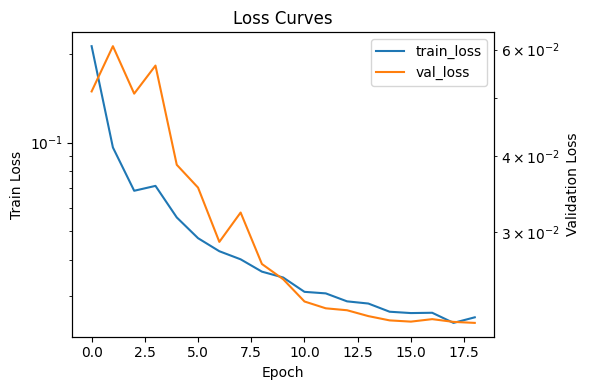

In [6]:
hpo_output = load_step_output(run, "tune_model")
train_output = load_step_output(run, "train_model")
evaluate_output = load_step_output(run, "evaluate_model")
export_output = load_step_output(run, "export_model")

hpo_params = hpo_output.get("hpo_params") if isinstance(hpo_output, dict) else hpo_output
trained_module = train_output.get("module") if isinstance(train_output, dict) else train_output
metrics = evaluate_output.get("metrics") if isinstance(evaluate_output, dict) else evaluate_output

summary = dict(metrics or {})
summary.pop("train_loss_history", None)
summary.pop("val_loss_history", None)

print("hpo_params:", hpo_params)
print("metrics (summary):", summary)
print("export:", export_output)

from pioneerml.evaluation.plots.loss import LossCurvesPlot

if trained_module is None:
    raise RuntimeError("No trained module loaded from pipeline run.")

LossCurvesPlot().render(
    trained_module,
    val_accuracy=(metrics.get("accuracy") if isinstance(metrics, dict) else None),
    show=True,
)
